# Complaint Urgency Modeling Workflow

This notebook creates the **fixed stratified train/validation/test split**, report-ready exploratory figures, a training-only TF-IDF vectorizer, and the four required model implementations. Model configurations are selected only by validation macro-F1; held-out test evaluation begins in final evaluation.

For reproducibility, select **Kernel → Restart Kernel and Run All**. Do not change the seed or regenerate split IDs once models have been trained.

In [ ]:
from __future__ import annotations

import importlib.metadata
import json
import platform
import random
import sys
from pathlib import Path

try:
    import joblib
    import matplotlib.pyplot as plt
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    from transformers import AutoTokenizer
except ImportError as error:
    raise RuntimeError("Install the notebook dependencies first: python3 -m pip install -r requirements.txt") from error

SEED = 20260815
MAX_LENGTH = 256
CHUNK_STRIDE = 64
TOKENIZER_MODEL = "distilbert-base-uncased"
random.seed(SEED)

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "data").is_dir():
    raise RuntimeError("Open this notebook from the project root or its notebooks/ directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


SOURCE_PATH = ROOT / "data/processed/cfpb_labeled_3000.csv"
SPLITS_DIR = ROOT / "data/splits"
REPORTS_DIR = ROOT / "data/reports"
FIGURES_DIR = REPORTS_DIR / "figures"
ARTIFACTS_DIR = ROOT / "artifacts"
for directory in (SPLITS_DIR, REPORTS_DIR, FIGURES_DIR, ARTIFACTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Split seed: {SEED}")
print(f"DistilBERT maximum sequence length: {MAX_LENGTH} tokens")

Project root: /Users/leongshiwei/ShiWei_Local_Mac/1_Projects/Local_RDS_Y2S1/AI-Asgmt
Split seed: 20260815
DistilBERT maximum sequence length: 256 tokens


In [ ]:
from __future__ import annotations

import hashlib
import csv
import json
import re
from collections import Counter
from collections.abc import Mapping, Sequence
from pathlib import Path


VALID_LABELS = ("Low", "Medium", "High")
SPLIT_TARGETS = {"train": 2_100, "validation": 450, "test": 450}
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NUMBER_RE = re.compile(r"\b\d+(?:[.,]\d+)?\b")
WORD_RE = re.compile(r"[a-z]+")


def stable_rank(complaint_id: str, seed: int) -> str:
    return hashlib.sha256(f"{seed}:{complaint_id}".encode("utf-8")).hexdigest()


def validate_labeled_rows(rows: Sequence[Mapping[str, str]]) -> None:
    if len(rows) != 3_000:
        raise ValueError(f"Expected 3,000 labeled records, found {len(rows)}.")
    complaint_ids: set[str] = set()
    for row in rows:
        complaint_id = row.get("complaint_id", "").strip()
        if not complaint_id:
            raise ValueError("missing complaint_id")
        if complaint_id in complaint_ids:
            raise ValueError(f"duplicate complaint_id {complaint_id}")
        complaint_ids.add(complaint_id)
        if not row.get("narrative", "").strip():
            raise ValueError(f"missing narrative for complaint_id {complaint_id}")
        if row.get("urgency_label", "").strip() not in VALID_LABELS:
            raise ValueError(f"invalid urgency_label {row.get('urgency_label', '')!r}")


def proportional_allocation(label_counts: Mapping[str, int], target: int) -> dict[str, int]:
    total = sum(label_counts.values())
    if target > total:
        raise ValueError(f"Cannot allocate {target} records from {total} records.")
    allocations = {label: (count * target) // total for label, count in label_counts.items()}
    remaining = target - sum(allocations.values())
    order = sorted(
        label_counts,
        key=lambda label: (-(label_counts[label] * target % total), label),
    )
    for label in order[:remaining]:
        allocations[label] += 1
    return allocations


def create_stratified_splits(
    rows: Sequence[Mapping[str, str]], seed: int
) -> dict[str, list[dict[str, str]]]:
    validate_labeled_rows(rows)
    by_label = {label: [] for label in VALID_LABELS}
    for row in rows:
        by_label[row["urgency_label"]].append(dict(row))
    counts = Counter({label: len(label_rows) for label, label_rows in by_label.items()})
    train_allocation = proportional_allocation(counts, SPLIT_TARGETS["train"])
    validation_allocation = proportional_allocation(counts, SPLIT_TARGETS["validation"])
    splits = {name: [] for name in SPLIT_TARGETS}
    for label, label_rows in by_label.items():
        ranked = sorted(label_rows, key=lambda row: stable_rank(row["complaint_id"], seed))
        train_end = train_allocation[label]
        validation_end = train_end + validation_allocation[label]
        splits["train"].extend(ranked[:train_end])
        splits["validation"].extend(ranked[train_end:validation_end])
        splits["test"].extend(ranked[validation_end:])
    return splits


def normalize_text(value: str) -> str:
    normalized = EMAIL_RE.sub(" emailtoken ", value.lower())
    normalized = URL_RE.sub(" urltoken ", normalized)
    normalized = NUMBER_RE.sub(" numtoken ", normalized)
    return " ".join(WORD_RE.findall(normalized))


def mean_pool_document_logits(
    chunk_logits: Sequence[Sequence[float]],
    document_ids: Sequence[int],
    document_count: int,
) -> list[list[float]]:
    """Return one mean logit vector for every source document."""
    if len(chunk_logits) != len(document_ids):
        raise ValueError("chunk_logits and document_ids must have the same length.")

    pooled_logits: list[list[float]] = []
    for document_id in range(document_count):
        rows = [logits for logits, source_id in zip(chunk_logits, document_ids) if source_id == document_id]
        if not rows:
            raise ValueError(f"No chunks for document {document_id}")
        pooled_logits.append([
            sum(row[class_id] for row in rows) / len(rows)
            for class_id in range(len(rows[0]))
        ])
    return pooled_logits


def sha256_file(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def write_split_artifacts(
    splits: Mapping[str, Sequence[Mapping[str, str]]],
    source_path: Path,
    output_dir: Path,
    seed: int,
) -> Path:
    if {name: len(rows) for name, rows in splits.items()} != SPLIT_TARGETS:
        raise ValueError("Split counts must be exactly train=2100, validation=450, test=450.")
    output_dir.mkdir(parents=True, exist_ok=True)
    for split_name, rows in splits.items():
        with (output_dir / f"{split_name}_ids.csv").open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=("complaint_id",))
            writer.writeheader()
            writer.writerows({"complaint_id": row["complaint_id"]} for row in rows)
    manifest = {
        "class_counts": {
            split_name: dict(sorted(Counter(row["urgency_label"] for row in rows).items()))
            for split_name, rows in splits.items()
        },
        "seed": seed,
        "source_path": str(source_path),
        "source_sha256": sha256_file(source_path),
        "split_counts": {split_name: len(rows) for split_name, rows in sorted(splits.items())},
        "stratify_column": "urgency_label",
    }
    path = output_dir / "split_manifest.json"
    path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    return path


## 1. Load and validate the frozen labeled dataset

The source file is treated as immutable. The checks below enforce the required 3,000 unique complaint IDs, complete narratives, and the approved Low/Medium/High label set.

In [2]:
if not SOURCE_PATH.is_file():
    raise FileNotFoundError(f"Frozen labeled dataset not found: {SOURCE_PATH}")

dataset = pd.read_csv(SOURCE_PATH, dtype=str, keep_default_na=False)
validate_labeled_rows(dataset.to_dict(orient="records"))
dataset = dataset.sort_values("complaint_id").reset_index(drop=True)

print(f"Validated {len(dataset):,} labeled complaints.")
display(dataset.head(3))
display(dataset["urgency_label"].value_counts().rename_axis("urgency_label").to_frame("count"))

Validated 3,000 labeled complaints.


,complaint_id,date_received,product,issue,narrative,urgency_label
0,18326369,2025-12-28,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,I'm really not sure what happened. I have mail...,Medium
1,18326378,2025-12-28,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Hello my name is XXXX XXXX XXXX XXXX XXXX XXXX...,Medium
2,18326406,2025-12-28,Credit reporting or other personal consumer re...,Incorrect information on your report,My name is XXXX XXXX this complaint is not mad...,Medium


,count
urgency_label,
Medium,2148
High,562
Low,290


## 2. Create, persist, and verify the fixed stratified split

Each model must use these same IDs. Splitting is deterministic from the complaint ID and seed `20260815`; the helper writes the ID-only files and a manifest containing the input hash and class allocation.

In [3]:
split_rows = create_stratified_splits(dataset.to_dict(orient="records"), seed=SEED)
manifest_path = write_split_artifacts(split_rows, SOURCE_PATH, SPLITS_DIR, seed=SEED)

train_ids = pd.read_csv(SPLITS_DIR / "train_ids.csv", dtype=str)["complaint_id"]
validation_ids = pd.read_csv(SPLITS_DIR / "validation_ids.csv", dtype=str)["complaint_id"]
test_ids = pd.read_csv(SPLITS_DIR / "test_ids.csv", dtype=str)["complaint_id"]
assert len(train_ids) == 2_100 and len(validation_ids) == 450 and len(test_ids) == 450
assert not set(train_ids).intersection(validation_ids)
assert not set(train_ids).intersection(test_ids)
assert not set(validation_ids).intersection(test_ids)
assert set(train_ids) | set(validation_ids) | set(test_ids) == set(dataset["complaint_id"])

split_lookup = {"train": set(train_ids), "validation": set(validation_ids), "test": set(test_ids)}
train = dataset[dataset["complaint_id"].isin(split_lookup["train"])].copy()
validation = dataset[dataset["complaint_id"].isin(split_lookup["validation"])].copy()
test = dataset[dataset["complaint_id"].isin(split_lookup["test"])].copy()

split_summary = pd.DataFrame({
    name: frame["urgency_label"].value_counts().reindex(["Low", "Medium", "High"], fill_value=0)
    for name, frame in (("train", train), ("validation", validation), ("test", test))
})
split_summary.loc["Total"] = split_summary.sum(axis=0)
display(split_summary)
print(f"Split manifest: {manifest_path.relative_to(ROOT)}")

,train,validation,test
urgency_label,,,
Low,203,44,43
Medium,1504,322,322
High,393,84,85
Total,2100,450,450


Split manifest: data/splits/split_manifest.json


## 3. Exploratory data analysis

These descriptive outputs are created from the full frozen dataset for reporting. They are not model-selection metrics and do not inspect test performance.

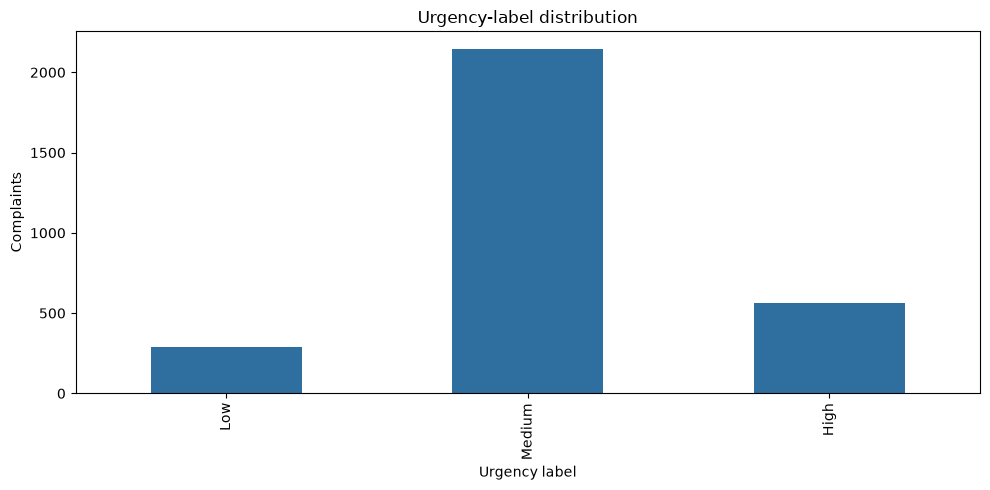

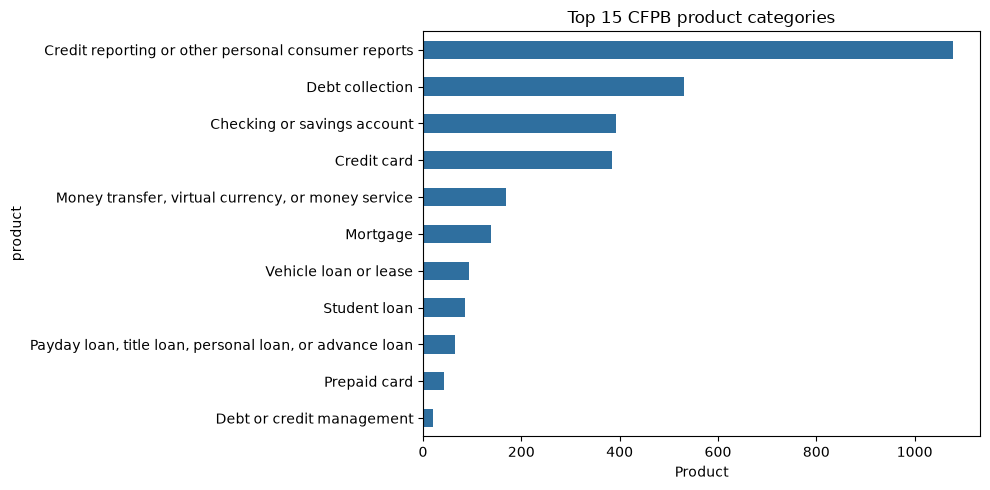

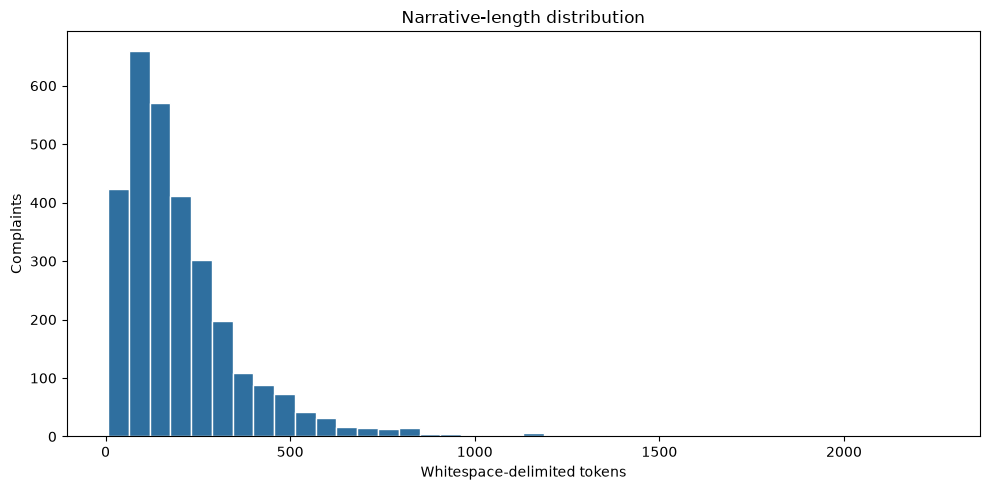

,narrative_character_count,narrative_whitespace_token_count
count,3000.000000,3000.000000
mean,1255.222667,207.708333
std,1161.063904,187.834398
min,50.000000,7.000000
25%,534.000000,90.750000
50%,953.000000,159.000000
75%,1599.250000,265.250000
95%,3205.550000,535.050000
max,13141.000000,2256.000000


In [4]:
dataset["narrative_character_count"] = dataset["narrative"].str.len()
dataset["narrative_whitespace_token_count"] = dataset["narrative"].str.split().str.len()
missingness = {column: int(dataset[column].eq("").sum()) for column in dataset.columns if column not in {"narrative_character_count", "narrative_whitespace_token_count"}}
length_summary = {
    measure: {statistic: float(value) for statistic, value in dataset[measure].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).items()}
    for measure in ("narrative_character_count", "narrative_whitespace_token_count")
}
exploration = {
    "row_count": int(len(dataset)),
    "missing_values": missingness,
    "urgency_class_distribution": {label: int(count) for label, count in dataset["urgency_label"].value_counts().sort_index().items()},
    "product_distribution": {product: int(count) for product, count in dataset["product"].value_counts().items()},
    "narrative_length_summary": length_summary,
}
(REPORTS_DIR / "phase4_data_exploration.json").write_text(json.dumps(exploration, indent=2, sort_keys=True) + "\n", encoding="utf-8")

def save_count_plot(counts, title, x_label, output_name, horizontal=False):
    figure, axis = plt.subplots(figsize=(10, 5))
    if horizontal:
        counts.sort_values().plot.barh(ax=axis, color="#2f6f9f")
        axis.set_xlabel("Complaints")
    else:
        counts.plot.bar(ax=axis, color="#2f6f9f")
        axis.set_ylabel("Complaints")
    axis.set_title(title)
    axis.set_xlabel(x_label)
    figure.tight_layout()
    figure.savefig(FIGURES_DIR / output_name, format="svg", bbox_inches="tight")
    plt.show()
    plt.close(figure)

save_count_plot(dataset["urgency_label"].value_counts().reindex(["Low", "Medium", "High"]), "Urgency-label distribution", "Urgency label", "phase4_class_distribution.svg")
top_products = dataset["product"].value_counts().head(15)
save_count_plot(top_products, "Top 15 CFPB product categories", "Product", "phase4_product_distribution.svg", horizontal=True)
figure, axis = plt.subplots(figsize=(10, 5))
axis.hist(dataset["narrative_whitespace_token_count"], bins=40, color="#2f6f9f", edgecolor="white")
axis.set(title="Narrative-length distribution", xlabel="Whitespace-delimited tokens", ylabel="Complaints")
figure.tight_layout()
figure.savefig(FIGURES_DIR / "phase4_narrative_length_distribution.svg", format="svg", bbox_inches="tight")
plt.show()
plt.close(figure)

display(pd.DataFrame(exploration["narrative_length_summary"]))

## 4. Training-only classical-model preprocessing

The vectorizer is fitted once on training narratives only. Validation and test narratives are transformed using that frozen vocabulary; they are never passed to `fit` or `fit_transform`.

In [5]:
vectorizer = TfidfVectorizer(
    preprocessor=normalize_text,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,
    min_df=2,
)
X_train = vectorizer.fit_transform(train["narrative"])
X_validation = vectorizer.transform(validation["narrative"])
X_test = vectorizer.transform(test["narrative"])
assert X_train.shape[0] == len(train)
assert X_validation.shape[0] == len(validation)
assert X_test.shape[0] == len(test)

vectorizer_path = ARTIFACTS_DIR / "tfidf_vectorizer.joblib"
joblib.dump(vectorizer, vectorizer_path)
print(f"Fitted {X_train.shape[1]:,} training-only TF-IDF features.")
print(f"Saved vectorizer: {vectorizer_path.relative_to(ROOT)}")

Fitted 27,493 training-only TF-IDF features.
Saved vectorizer: artifacts/tfidf_vectorizer.joblib


## 5. DistilBERT tokenizer preparation

The later three-class fine-tuning stage uses `distilbert-base-uncased`. Text is truncated to **256 tokens**; padding is deferred to the batch data collator so each batch pads only as much as necessary. This cell downloads the tokenizer to the normal Hugging Face cache on first use but does not download or train a classification model.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_MODEL)
untruncated_train = tokenizer(train["narrative"].tolist(), truncation=False, add_special_tokens=True)
train_truncation_rate = sum(len(ids) > MAX_LENGTH for ids in untruncated_train["input_ids"]) / len(train)

tokenized_train = tokenizer(train["narrative"].tolist(), truncation=True, max_length=256, padding=False)
tokenized_validation = tokenizer(validation["narrative"].tolist(), truncation=True, max_length=256, padding=False)
tokenized_test = tokenizer(test["narrative"].tolist(), truncation=True, max_length=256, padding=False)
assert len(tokenized_train["input_ids"]) == len(train)
assert len(tokenized_validation["input_ids"]) == len(validation)
assert len(tokenized_test["input_ids"]) == len(test)

print(f"Tokenizer: {TOKENIZER_MODEL}")
print(f"Maximum sequence length: {MAX_LENGTH} tokens")
print(f"Training narratives truncated at {MAX_LENGTH} tokens: {train_truncation_rate:.1%}")

Token indices sequence length is longer than the specified maximum sequence length for this model (1221 > 512). Running this sequence through the model will result in indexing errors


Tokenizer: distilbert-base-uncased
Maximum sequence length: 256 tokens
Training narratives truncated at 256 tokens: 43.1%


## 6. Record the data preparation environment

The generated environment record documents library versions, platform details, the fixed seed, vectorizer configuration, and tokenizer settings. The following validation training cells reuse the fixed split and training-only TF-IDF feature space.

In [7]:
def distribution_version(distribution):
    try:
        return importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        return "not installed (required for validation training DistilBERT training)"

package_versions = {package: distribution_version(package) for package in ("pandas", "scikit-learn", "matplotlib", "joblib", "jupyter", "transformers", "torch")}
environment = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "processor": platform.processor(),
    "package_versions": package_versions,
    "random_seed": SEED,
    "input_dataset": str(SOURCE_PATH.relative_to(ROOT)),
    "split_targets": {"train": 2100, "validation": 450, "test": 450},
    "classical_preprocessing": {"normalization": "lowercase, email/url/number placeholders, alphabetic tokens", "ngram_range": [1, 2], "stop_words": "english", "sublinear_tf": True, "min_df": 2, "fit_split": "train"},
    "distilbert_preprocessing": {"model": TOKENIZER_MODEL, "chunking": True, "chunk_stride": CHUNK_STRIDE, "truncation": True, "max_length": MAX_LENGTH, "aggregation": "mean_logits", "padding": "max_length", "training_truncation_rate": train_truncation_rate},
}
environment_path = REPORTS_DIR / "phase4_experiment_environment.json"
environment_path.write_text(json.dumps(environment, indent=2, sort_keys=True) + "\n", encoding="utf-8")

for path in (manifest_path, REPORTS_DIR / "phase4_data_exploration.json", environment_path, vectorizer_path):
    print(path.relative_to(ROOT))

print("validation training follows below, using the fixed split IDs and training-only TF-IDF vectorizer.")

data/splits/split_manifest.json
data/reports/phase4_data_exploration.json
data/reports/phase4_experiment_environment.json
artifacts/tfidf_vectorizer.joblib
validation training follows below, using the fixed split IDs and training-only TF-IDF vectorizer.


## 7. Validation-only model training

All four models use the frozen training and validation records from data preparation. **The held-out test split is not used in any validation training fit, prediction, metric, or configuration choice.** Macro-F1 on the validation split selects each final configuration.

In [8]:
import copy
import time

import numpy as np
try:
    import torch
    import torch.nn.functional as F
    from torch.optim import AdamW
    from torch.utils.data import DataLoader, Dataset
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report, f1_score
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.svm import LinearSVC
    from transformers import AutoModelForSequenceClassification
except ImportError as error:
    raise RuntimeError("validation training requires the packages in requirements.txt, including PyTorch.") from error

LABEL_ORDER = ["Low", "Medium", "High"]
LABEL_TO_ID = {label: index for index, label in enumerate(LABEL_ORDER)}
ID_TO_LABEL = {index: label for label, index in LABEL_TO_ID.items()}
y_train = train["urgency_label"].to_numpy()
y_validation = validation["urgency_label"].to_numpy()
MODEL_DIR = ARTIFACTS_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def validation_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=LABEL_ORDER, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, labels=LABEL_ORDER, average="weighted", zero_division=0)),
        "per_class": classification_report(y_true, y_pred, labels=LABEL_ORDER, output_dict=True, zero_division=0),
    }

validation_results = {}
print(f"Training labels: {dict(train['urgency_label'].value_counts().sort_index())}")

Training labels: {'High': np.int64(393), 'Low': np.int64(203), 'Medium': np.int64(1504)}


### 7.1 Classical models — Multinomial NB, Logistic Regression, and calibrated Linear SVM

Each candidate is fitted only with `X_train`. Logistic Regression and Linear SVM use balanced class weights derived internally from training labels. The SVM is wrapped in five-fold sigmoid calibration, so its prototype confidence can be labelled calibrated.

In [9]:
candidate_factories = {
    "multinomial_nb": [({"alpha": alpha}, lambda alpha=alpha: MultinomialNB(alpha=alpha)) for alpha in (0.1, 0.5, 1.0)],
    "logistic_regression": [({"C": c, "class_weight": "balanced", "max_iter": 5000}, lambda c=c: LogisticRegression(C=c, class_weight="balanced", max_iter=5000, random_state=SEED)) for c in (0.1, 1.0, 10.0)],
    "linear_svm_calibrated": [({"C": c, "class_weight": "balanced", "max_iter": 10000, "calibration": "sigmoid_cv_5"}, lambda c=c: CalibratedClassifierCV(LinearSVC(C=c, class_weight="balanced", max_iter=10000, random_state=SEED), method="sigmoid", cv=5)) for c in (0.1, 1.0, 10.0)],
}

for model_name, candidates in candidate_factories.items():
    candidate_scores = []
    selected_model, selected_parameters, selected_metrics = None, None, None
    for parameters, factory in candidates:
        started_at = time.perf_counter()
        candidate = factory()
        candidate.fit(X_train, y_train)
        metrics = validation_metrics(y_validation, candidate.predict(X_validation))
        candidate_scores.append({"hyperparameters": parameters, "macro_f1": metrics["macro_f1"]})
        if selected_metrics is None or metrics["macro_f1"] > selected_metrics["macro_f1"]:
            selected_model, selected_parameters, selected_metrics = candidate, parameters, metrics
            selected_fit_seconds = time.perf_counter() - started_at
    output_path = MODEL_DIR / f"{model_name}.joblib"
    joblib.dump(selected_model, output_path)
    validation_results[model_name] = {
        "fit_split": "train",
        "selection_metric": "validation_macro_f1",
        "selected_hyperparameters": selected_parameters,
        "candidate_macro_f1": candidate_scores,
        "validation_metrics": selected_metrics,
        "selected_fit_seconds": float(selected_fit_seconds),
        "model_path": str(output_path.relative_to(ROOT)),
    }

display(pd.DataFrame({name: {"validation_macro_f1": result["validation_metrics"]["macro_f1"], "selected_hyperparameters": result["selected_hyperparameters"]} for name, result in validation_results.items()}).T)

/Users/leongshiwei/ShiWei_Local_Mac/1_Projects/Local_RDS_Y2S1/AI-Asgmt/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leongshiwei/ShiWei_Local_Mac/1_Projects/Local_RDS_Y2S1/AI-Asgmt/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/leongshiwei/ShiWei_Local_Mac/1_Projects/Local_RDS_Y2S1/AI-Asgmt/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,validation_macro_f1,selected_hyperparameters
multinomial_nb,0.529009,{'alpha': 0.1}
logistic_regression,0.657589,"{'C': 1.0, 'class_weight': 'balanced', 'max_it..."
linear_svm_calibrated,0.630209,"{'C': 1.0, 'class_weight': 'balanced', 'calibr..."


### 7.2 DistilBERT — three-class fine-tuning with validation early stopping

DistilBERT is fine-tuned only with training records. Training uses inverse-frequency class weights computed from the training labels, checks validation macro-F1 at the end of each epoch, and stops after two non-improving epochs (at most five epochs). The best validation checkpoint is restored and saved.

In [10]:
class ComplaintDataset(Dataset):
    def __init__(self, narratives, labels):
        self.encodings = tokenizer(
            narratives, truncation=True, max_length=MAX_LENGTH, stride=CHUNK_STRIDE,
            return_overflowing_tokens=True, padding="max_length",
        )
        self.document_ids = self.encodings.pop("overflow_to_sample_mapping")
        self.labels = labels
        if set(self.document_ids) != set(range(len(labels))):
            raise ValueError("Every narrative must produce at least one chunk.")

    def __len__(self):
        return len(self.document_ids)

    def __getitem__(self, index):
        document_id = self.document_ids[index]
        item = {key: torch.tensor(value[index]) for key, value in self.encodings.items()}
        item["document_id"] = torch.tensor(document_id)
        item["labels"] = torch.tensor(self.labels[document_id])
        return item

torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

train_label_ids = [LABEL_TO_ID[label] for label in y_train]
validation_label_ids = [LABEL_TO_ID[label] for label in y_validation]
train_dataset = ComplaintDataset(train["narrative"].tolist(), train_label_ids)
validation_dataset = ComplaintDataset(validation["narrative"].tolist(), validation_label_ids)
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, generator=loader_generator)
validation_loader = DataLoader(validation_dataset, batch_size=8, shuffle=False)
class_counts = np.bincount(train_label_ids, minlength=len(LABEL_ORDER))
class_weights = torch.tensor(len(train_label_ids) / (len(LABEL_ORDER) * class_counts), dtype=torch.float32, device=device)

bert_model = AutoModelForSequenceClassification.from_pretrained(TOKENIZER_MODEL, num_labels=len(LABEL_ORDER), id2label=ID_TO_LABEL, label2id=LABEL_TO_ID).to(device)
optimizer = AdamW(bert_model.parameters(), lr=2e-5)
best_state, best_validation_metrics, best_epoch, epochs_without_improvement = None, None, 0, 0
epoch_history = []
training_started_at = time.perf_counter()

for epoch in range(1, 6):
    bert_model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        labels = batch.pop("labels").to(device)
        batch.pop("document_id")
        inputs = {key: value.to(device) for key, value in batch.items()}
        optimizer.zero_grad()
        logits = bert_model(**inputs).logits
        loss = F.cross_entropy(logits, labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    bert_model.eval()
    validation_chunk_logits = []
    validation_document_ids = []
    with torch.no_grad():
        for batch in validation_loader:
            batch.pop("labels")
            validation_document_ids.extend(batch.pop("document_id").tolist())
            inputs = {key: value.to(device) for key, value in batch.items()}
            validation_chunk_logits.extend(bert_model(**inputs).logits.cpu().tolist())
    validation_document_logits = mean_pool_document_logits(
        validation_chunk_logits, validation_document_ids, document_count=len(validation),
    )
    validation_predictions = np.argmax(validation_document_logits, axis=1).tolist()
    epoch_metrics = validation_metrics(y_validation, [ID_TO_LABEL[index] for index in validation_predictions])
    epoch_metrics["epoch"] = epoch
    epoch_metrics["mean_training_loss"] = epoch_loss / len(train_loader)
    epoch_history.append(epoch_metrics)
    if best_validation_metrics is None or epoch_metrics["macro_f1"] > best_validation_metrics["macro_f1"]:
        best_state = {key: value.detach().cpu().clone() for key, value in bert_model.state_dict().items()}
        best_validation_metrics, best_epoch, epochs_without_improvement = epoch_metrics, epoch, 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= 2:
            break

bert_model.load_state_dict(best_state)
bert_directory = MODEL_DIR / "distilbert"
bert_directory.mkdir(parents=True, exist_ok=True)
bert_model.save_pretrained(bert_directory)
tokenizer.save_pretrained(bert_directory)
training_summary = {
    "device": str(device),
    "epochs_completed": len(epoch_history),
    "best_epoch": best_epoch,
    "patience": 2,
    "chunking": True,
    "chunk_stride": CHUNK_STRIDE,
    "aggregation": "mean_logits",
    "history": epoch_history,
    "training_seconds": float(time.perf_counter() - training_started_at),
}
(bert_directory / "training_summary.json").write_text(json.dumps(training_summary, indent=2, sort_keys=True) + "\n", encoding="utf-8")
validation_results["distilbert"] = {
    "fit_split": "train",
    "selection_metric": "validation_macro_f1",
    "selected_hyperparameters": {"learning_rate": 2e-5, "batch_size": 8, "max_epochs": 5, "patience": 2, "max_length": MAX_LENGTH, "chunking": True, "chunk_stride": CHUNK_STRIDE, "aggregation": "mean_logits", "class_weights": "inverse_frequency_from_train"},
    "validation_metrics": best_validation_metrics,
    "early_stopping": training_summary,
    "model_path": str(bert_directory.relative_to(ROOT)),
}
print(f"DistilBERT selected epoch {best_epoch} with validation macro-F1 {best_validation_metrics['macro_f1']:.4f} on {device}.")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT selected epoch 5 with validation macro-F1 0.7225 on mps.


### 7.3 Freeze validation selections

This report records every classical candidate, each selected configuration, and the selected DistilBERT checkpoint. It is the final evaluation input; no model should be retuned after this point.

In [11]:
validation_report = {
    "label_order": LABEL_ORDER,
    "selection_metric": "validation_macro_f1",
    "test_set_accessed_for_modeling": False,
    "models": validation_results,
}
validation_report_path = REPORTS_DIR / "phase5_validation_metrics.json"
validation_report_path.write_text(json.dumps(validation_report, indent=2, sort_keys=True) + "\n", encoding="utf-8")
display(pd.DataFrame({name: {"macro_f1": result["validation_metrics"]["macro_f1"], "accuracy": result["validation_metrics"]["accuracy"], "hyperparameters": result["selected_hyperparameters"]} for name, result in validation_results.items()}).T)
print(f"Frozen validation selections: {validation_report_path.relative_to(ROOT)}")

,macro_f1,accuracy,hyperparameters
multinomial_nb,0.529009,0.782222,{'alpha': 0.1}
logistic_regression,0.657589,0.76,"{'C': 1.0, 'class_weight': 'balanced', 'max_it..."
linear_svm_calibrated,0.630209,0.795556,"{'C': 1.0, 'class_weight': 'balanced', 'calibr..."
distilbert,0.722458,0.804444,"{'learning_rate': 2e-05, 'batch_size': 8, 'max..."


Frozen validation selections: data/reports/phase5_validation_metrics.json


## 8. Final evaluation — Frozen held-out evaluation and error analysis

This section loads the four **frozen validation artifacts** and evaluates them on the fixed 450-record test split. It does not retrain, tune, recalibrate, or replace any model. Artifact hashes are recorded before the test labels are used, and a completed result bundle prevents accidental repeat evaluation. Re-running these cells loads the saved final evaluation evidence instead of scoring the test set again.

**Timing protocol.** The recorded fit times are not standardized across model families: each classical value covers only the selected estimator's `.fit()` call and excludes TF-IDF fitting and the complete candidate search, whereas DistilBERT covers its five-epoch training loop including validation passes. Artifact loading is measured separately and excluded from prediction timing. End-to-end prediction time includes TF-IDF transformation for classical models and tokenization, overlapping chunk creation, inference, and mean-logit pooling for DistilBERT. Classical inference is timed over 10 full-test repetitions after one unrecorded warm-up; DistilBERT is timed over three full-test repetitions after one unrecorded warm-up. These repetitions estimate steady-state runtime only and do not change the predictive metrics. LIME timing uses the same privacy-reviewed correctly classified High example and 250 perturbations per explanation; classical values are means of three runs, while the DistilBERT value is one run because of its substantially higher inference cost. All timings describe this machine and execution session. LIME is a local approximation, not a causal explanation.


In [ ]:
import hashlib
import json
import statistics
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lime.lime_text import LimeTextExplainer
from src import text_preprocessing as _text_preprocessing
from transformers import AutoModelForSequenceClassification, AutoTokenizer

SEED = 20260815
MAX_LENGTH = 256
CHUNK_STRIDE = 64
LABEL_ORDER = ["Low", "Medium", "High"]
ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "data").is_dir():
    raise RuntimeError("Open this notebook from the project root or its notebooks/ directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
SOURCE_PATH = ROOT / "data/processed/cfpb_labeled_3000.csv"
SPLITS_DIR = ROOT / "data/splits"
REPORTS_DIR = ROOT / "data/reports"
FIGURES_DIR = REPORTS_DIR / "figures"
ARTIFACTS_DIR = ROOT / "artifacts"
MODEL_DIR = ARTIFACTS_DIR / "models"
for directory in (REPORTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

EVALUATION_RESULTS_PATH = REPORTS_DIR / "phase6_test_results.json"
EVALUATION_PREDICTIONS_PATH = REPORTS_DIR / "phase6_test_predictions.csv"
EVALUATION_EFFICIENCY_PATH = REPORTS_DIR / "phase6_efficiency.csv"
EVALUATION_ERRORS_PATH = REPORTS_DIR / "phase6_error_analysis.csv"
EVALUATION_FREEZE_PATH = REPORTS_DIR / "phase6_freeze_manifest.json"
VALIDATION_REPORT_PATH = REPORTS_DIR / "phase5_validation_metrics.json"
DISPLAY_NAMES = {
    "multinomial_nb": "Multinomial Naive Bayes",
    "logistic_regression": "Logistic Regression",
    "linear_svm_calibrated": "Calibrated Linear SVM",
    "distilbert": "DistilBERT",
}
MODEL_PATHS = {
    "multinomial_nb": MODEL_DIR / "multinomial_nb.joblib",
    "logistic_regression": MODEL_DIR / "logistic_regression.joblib",
    "linear_svm_calibrated": MODEL_DIR / "linear_svm_calibrated.joblib",
    "distilbert": MODEL_DIR / "distilbert",
}
REQUIRED_FROZEN_PATHS = {
    "source_dataset": SOURCE_PATH,
    "test_ids": SPLITS_DIR / "test_ids.csv",
    "split_manifest": SPLITS_DIR / "split_manifest.json",
    "validation_report": VALIDATION_REPORT_PATH,
    "tfidf_vectorizer": ARTIFACTS_DIR / "tfidf_vectorizer.joblib",
    **{f"model_{name}": path for name, path in MODEL_PATHS.items()},
}


def sha256_path(path):
    path = Path(path)
    digest = hashlib.sha256()
    files = sorted(path.rglob("*")) if path.is_dir() else [path]
    for file_path in files:
        if file_path.is_file():
            digest.update(str(file_path.relative_to(path) if path.is_dir() else file_path.name).encode("utf-8"))
            digest.update(file_path.read_bytes())
    return digest.hexdigest()


missing_paths = [str(path) for path in REQUIRED_FROZEN_PATHS.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Frozen validation inputs are missing: {missing_paths}")

freeze_snapshot = {
    "frozen_before_test_evaluation": True,
    "label_order": LABEL_ORDER,
    "test_record_count": 450,
    "artifact_sha256": {name: sha256_path(path) for name, path in REQUIRED_FROZEN_PATHS.items()},
    "git_commit_at_freeze": subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip(),
    "no_post_test_tuning_rule": "Models must not be retrained, tuned, recalibrated, or replaced in response to held-out results.",
}
if EVALUATION_FREEZE_PATH.exists():
    recorded_freeze = json.loads(EVALUATION_FREEZE_PATH.read_text(encoding="utf-8"))
    if recorded_freeze["artifact_sha256"] != freeze_snapshot["artifact_sha256"]:
        raise RuntimeError("Frozen artifact hashes changed after the final evaluation boundary.")
else:
    EVALUATION_FREEZE_PATH.write_text(json.dumps(freeze_snapshot, indent=2, sort_keys=True) + "\n", encoding="utf-8")

RUN_FINAL_TEST_EVALUATION = not EVALUATION_RESULTS_PATH.exists()
print("Frozen inputs verified.")
print(f"Final test evaluation required: {RUN_FINAL_TEST_EVALUATION}")
if not RUN_FINAL_TEST_EVALUATION:
    print("Existing final evidence will be loaded without rescoring the test set.")


In [ ]:
from __future__ import annotations

import re
from collections.abc import Mapping, Sequence
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


MODEL_COLORS = {
    "multinomial_nb": "#4C78A8",
    "logistic_regression": "#F58518",
    "linear_svm_calibrated": "#54A24B",
    "distilbert": "#B279A2",
}
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NUMBER_RE = re.compile(r"\b\d+(?:[.,]\d+)?\b")


def compute_test_metrics(
    y_true: Sequence[str],
    y_pred: Sequence[str],
    label_order: Sequence[str],
) -> dict[str, object]:
    """Return aggregate, per-class, confusion, and safety metrics."""
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same length.")
    allowed = set(label_order)
    unknown = (set(y_true) | set(y_pred)) - allowed
    if unknown:
        raise ValueError(f"Labels outside label_order: {sorted(unknown)}")

    report = classification_report(
        y_true,
        y_pred,
        labels=list(label_order),
        output_dict=True,
        zero_division=0,
    )
    per_class = {
        label: {
            "precision": float(report[label]["precision"]),
            "recall": float(report[label]["recall"]),
            "f1": float(report[label]["f1-score"]),
            "support": int(report[label]["support"]),
        }
        for label in label_order
    }
    high_to_low = sum(
        actual == "High" and predicted == "Low"
        for actual, predicted in zip(y_true, y_pred)
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(report["macro avg"]["precision"]),
        "macro_recall": float(report["macro avg"]["recall"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_precision": float(report["weighted avg"]["precision"]),
        "weighted_recall": float(report["weighted avg"]["recall"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "high_recall": per_class["High"]["recall"],
        "high_to_low_errors": int(high_to_low),
        "per_class": per_class,
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=list(label_order)
        ).astype(int).tolist(),
    }


def artifact_size_bytes(paths: Sequence[Path | str]) -> int:
    """Sum unique persisted artifact files, traversing directories recursively."""
    files: set[Path] = set()
    for raw_path in paths:
        path = Path(raw_path).resolve()
        if not path.exists():
            raise FileNotFoundError(path)
        if path.is_dir():
            files.update(candidate.resolve() for candidate in path.rglob("*") if candidate.is_file())
        elif path.is_file():
            files.add(path)
    return sum(path.stat().st_size for path in files)


def privacy_excerpt(narrative: str, max_characters: int = 220) -> str:
    """Create a short review excerpt with common identifier-like strings redacted."""
    if max_characters < 2:
        raise ValueError("max_characters must be at least 2.")
    excerpt = EMAIL_RE.sub("[EMAIL]", narrative)
    excerpt = URL_RE.sub("[URL]", excerpt)
    excerpt = NUMBER_RE.sub("[NUMBER]", excerpt)
    excerpt = " ".join(excerpt.split())
    if len(excerpt) > max_characters:
        excerpt = excerpt[: max_characters - 1].rstrip() + "…"
    return excerpt


def select_representative_errors(
    predictions: pd.DataFrame,
    model_order: Sequence[str],
) -> pd.DataFrame:
    """Select deterministic safety, boundary, and long-document error examples."""
    required = {
        "complaint_id",
        "model",
        "actual_label",
        "predicted_label",
        "narrative",
        "narrative_token_count",
    }
    missing = required - set(predictions.columns)
    if missing:
        raise ValueError(f"Missing prediction columns: {sorted(missing)}")

    errors = predictions[
        predictions["actual_label"] != predictions["predicted_label"]
    ].copy()
    model_rank = {model: rank for rank, model in enumerate(model_order)}
    errors["_model_rank"] = errors["model"].map(model_rank).fillna(len(model_rank))
    errors = errors.sort_values(["_model_rank", "complaint_id"], kind="stable")

    chosen: list[pd.Series] = []
    chosen_indexes: set[object] = set()

    def choose(mask: pd.Series, pattern: str, factor: str, implication: str) -> None:
        candidates = errors[mask & ~errors.index.isin(chosen_indexes)]
        if candidates.empty:
            return
        row = candidates.iloc[0].copy()
        row["error_pattern"] = pattern
        row["likely_error_factor"] = factor
        row["safety_implication"] = implication
        chosen.append(row)
        chosen_indexes.add(candidates.index[0])

    choose(
        (errors["actual_label"] == "High") & (errors["predicted_label"] == "Low"),
        "High-to-Low safety-critical miss",
        "Urgent harm cues may be implicit, distant, or outweighed by routine language.",
        "The complaint could be under-triaged and receive an inappropriately slow response.",
    )
    choose(
        (errors["actual_label"] == "Low") & (errors["predicted_label"] == "Medium"),
        "Low-to-Medium boundary error",
        "Resolved or minor context may be outweighed by negative event vocabulary.",
        "The complaint may consume priority-review capacity unnecessarily.",
    )
    choose(
        (errors["actual_label"] == "Medium") & (errors["predicted_label"] == "High"),
        "Medium-to-High boundary error",
        "Severe wording may be present without evidence of immediate or continuing harm.",
        "The complaint may be over-escalated relative to the annotation guide.",
    )

    remaining = errors[~errors.index.isin(chosen_indexes)].sort_values(
        ["narrative_token_count", "_model_rank", "complaint_id"],
        ascending=[False, True, True],
        kind="stable",
    )
    if not remaining.empty:
        row = remaining.iloc[0].copy()
        row["error_pattern"] = "Long-document classification error"
        row["likely_error_factor"] = "Relevant evidence may be diluted across chunks or mixed with competing context."
        row["safety_implication"] = "Chunk aggregation can obscure a short but decision-critical passage."
        chosen.append(row)

    for _, candidate in errors.iterrows():
        if len(chosen) >= 4:
            break
        if candidate.name in chosen_indexes:
            continue
        row = candidate.copy()
        row["error_pattern"] = "Other representative classification error"
        row["likely_error_factor"] = "Narrative evidence is ambiguous or overlaps adjacent urgency definitions."
        row["safety_implication"] = "Human review remains necessary for borderline cases."
        chosen.append(row)
        chosen_indexes.add(candidate.name)

    columns = [
        "case",
        "complaint_id",
        "actual_label",
        "predicted_label",
        "model",
        "narrative_token_count",
        "privacy_reviewed_excerpt",
        "error_pattern",
        "likely_error_factor",
        "safety_implication",
    ]
    if not chosen:
        return pd.DataFrame(columns=columns)

    selected = pd.DataFrame(chosen[:4]).reset_index(drop=True)
    selected.insert(0, "case", [f"E{index}" for index in range(1, len(selected) + 1)])
    selected["privacy_reviewed_excerpt"] = selected["narrative"].map(privacy_excerpt)
    return selected[columns]


def _display_names(results: Mapping[str, Mapping[str, object]]) -> list[str]:
    return [str(result.get("display_name", model)) for model, result in results.items()]


def _save_figure(figure: plt.Figure, output_path: Path | str) -> Path:
    path = Path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout()
    figure.savefig(path, format="svg", bbox_inches="tight")
    plt.close(figure)
    return path


def plot_confusion_matrix(
    model_name: str,
    result: Mapping[str, object],
    label_order: Sequence[str],
    output_path: Path | str,
    maximum_count: int | None = None,
) -> Path:
    matrix = np.asarray(result["metrics"]["confusion_matrix"], dtype=int)
    maximum = maximum_count if maximum_count is not None else int(matrix.max())
    figure, axis = plt.subplots(figsize=(6.4, 5.2))
    image = axis.imshow(matrix, cmap="Blues", vmin=0, vmax=max(maximum, 1))
    threshold = max(maximum, 1) / 2
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(
                column,
                row,
                str(matrix[row, column]),
                ha="center",
                va="center",
                color="white" if matrix[row, column] > threshold else "#17202A",
                fontsize=12,
                fontweight="bold",
            )
    axis.set_xticks(range(len(label_order)), label_order)
    axis.set_yticks(range(len(label_order)), label_order)
    axis.set_xlabel("Predicted urgency")
    axis.set_ylabel("Actual urgency")
    axis.set_title(f"{result.get('display_name', model_name)} — held-out test confusion matrix")
    figure.colorbar(image, ax=axis, label="Complaints")
    return _save_figure(figure, output_path)


def plot_metric_comparison(
    results: Mapping[str, Mapping[str, object]],
    output_path: Path | str,
    title: str = "Held-out test performance across frozen models",
) -> Path:
    metric_specs = [
        ("accuracy", "Accuracy"),
        ("macro_f1", "Macro-F1"),
        ("weighted_f1", "Weighted-F1"),
        ("high_recall", "High recall"),
    ]
    x = np.arange(len(results))
    width = 0.19
    figure, axis = plt.subplots(figsize=(11, 5.8))
    for offset, (key, label) in enumerate(metric_specs):
        values = [float(result["metrics"][key]) for result in results.values()]
        bars = axis.bar(x + (offset - 1.5) * width, values, width, label=label)
        axis.bar_label(bars, fmt="%.3f", fontsize=8, padding=2, rotation=90)
    axis.set_xticks(x, _display_names(results), rotation=12, ha="right")
    axis.set_ylim(0, 1.08)
    axis.set_ylabel("Score")
    axis.set_title(title)
    axis.legend(ncol=4, loc="upper center")
    axis.grid(axis="y", alpha=0.25)
    return _save_figure(figure, output_path)


def plot_per_class_f1(
    results: Mapping[str, Mapping[str, object]],
    label_order: Sequence[str],
    output_path: Path | str,
) -> Path:
    x = np.arange(len(results))
    width = 0.24
    colors = ["#4C78A8", "#F2CF5B", "#E45756"]
    figure, axis = plt.subplots(figsize=(10.5, 5.8))
    for offset, (label, color) in enumerate(zip(label_order, colors)):
        values = [float(result["metrics"]["per_class"][label]["f1"]) for result in results.values()]
        bars = axis.bar(x + (offset - 1) * width, values, width, label=label, color=color)
        axis.bar_label(bars, fmt="%.3f", fontsize=8, padding=2, rotation=90)
    axis.set_xticks(x, _display_names(results), rotation=12, ha="right")
    axis.set_ylim(0, 1.08)
    axis.set_ylabel("F1-score")
    axis.set_title("Per-class F1 on the held-out test set")
    axis.legend(title="Actual class", ncol=3, loc="upper center")
    axis.grid(axis="y", alpha=0.25)
    return _save_figure(figure, output_path)


def plot_safety_metrics(
    results: Mapping[str, Mapping[str, object]], output_path: Path | str
) -> Path:
    names = _display_names(results)
    recalls = [float(result["metrics"]["high_recall"]) for result in results.values()]
    errors = [int(result["metrics"]["high_to_low_errors"]) for result in results.values()]
    colors = [MODEL_COLORS.get(model, "#4C78A8") for model in results]
    figure, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
    recall_bars = axes[0].bar(names, recalls, color=colors)
    axes[0].bar_label(recall_bars, fmt="%.3f", padding=3)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Recall")
    axes[0].set_title("High-urgency recall (higher is better)")
    error_bars = axes[1].bar(names, errors, color=colors)
    axes[1].bar_label(error_bars, fmt="%d", padding=3)
    axes[1].set_ylabel("Complaints")
    axes[1].set_title("High-to-Low errors (lower is better)")
    for axis in axes:
        axis.tick_params(axis="x", rotation=18)
        axis.grid(axis="y", alpha=0.25)
    figure.suptitle("Safety-oriented held-out test measures", fontsize=14)
    return _save_figure(figure, output_path)


def plot_performance_cost(
    results: Mapping[str, Mapping[str, object]], output_path: Path | str
) -> Path:
    figure, axis = plt.subplots(figsize=(9.5, 6))
    for model, result in results.items():
        latency = max(float(result["mean_prediction_ms"]), 0.001)
        macro_f1 = float(result["metrics"]["macro_f1"])
        size_mb = float(result["artifact_size_bytes"]) / (1024 * 1024)
        point_size = 90 + 80 * np.log10(max(size_mb, 0.1) + 1)
        axis.scatter(
            latency,
            macro_f1,
            s=point_size,
            color=MODEL_COLORS.get(model, "#4C78A8"),
            alpha=0.82,
            edgecolor="white",
            linewidth=1.2,
        )
        axis.annotate(
            f"{result.get('display_name', model)}\n{size_mb:.1f} MB",
            (latency, macro_f1),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
        )
    axis.set_xscale("log")
    axis.set_xlabel("Mean end-to-end prediction time per complaint (ms, log scale)")
    axis.set_ylabel("Test macro-F1")
    axis.set_title("Predictive performance versus deployment cost")
    axis.grid(alpha=0.25, which="both")
    return _save_figure(figure, output_path)


In [ ]:
def classical_probabilities(narratives, vectorizer, model):
    probabilities = model.predict_proba(vectorizer.transform(list(narratives)))
    class_indexes = [list(model.classes_).index(label) for label in LABEL_ORDER]
    return probabilities[:, class_indexes]


def distilbert_probabilities(narratives, tokenizer, model, device, batch_size=16):
    encoded = tokenizer(
        list(narratives),
        truncation=True,
        max_length=MAX_LENGTH,
        stride=CHUNK_STRIDE,
        return_overflowing_tokens=True,
        padding="max_length",
        return_tensors="pt",
    )
    document_ids = encoded.pop("overflow_to_sample_mapping").tolist()
    chunk_logits = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(document_ids), batch_size):
            inputs = {key: values[start:start + batch_size].to(device) for key, values in encoded.items()}
            chunk_logits.extend(model(**inputs).logits.cpu().tolist())
    pooled = np.asarray(mean_pool_document_logits(chunk_logits, document_ids, len(narratives)))
    pooled -= pooled.max(axis=1, keepdims=True)
    probabilities = np.exp(pooled)
    probabilities /= probabilities.sum(axis=1, keepdims=True)
    return probabilities, len(document_ids)


if not RUN_FINAL_TEST_EVALUATION:
    evaluation_results = json.loads(EVALUATION_RESULTS_PATH.read_text(encoding="utf-8"))
    evaluation_predictions = pd.read_csv(EVALUATION_PREDICTIONS_PATH, dtype={"complaint_id": str})
    evaluation_errors = pd.read_csv(EVALUATION_ERRORS_PATH, dtype={"complaint_id": str})
else:
    validation_report = json.loads(VALIDATION_REPORT_PATH.read_text(encoding="utf-8"))
    source_dataset = pd.read_csv(SOURCE_PATH, dtype=str, keep_default_na=False).set_index("complaint_id")
    final_test_ids = pd.read_csv(SPLITS_DIR / "test_ids.csv", dtype=str)["complaint_id"]
    if len(final_test_ids) != 450 or final_test_ids.duplicated().any():
        raise ValueError("Expected exactly 450 unique held-out complaint IDs.")
    final_test = source_dataset.loc[final_test_ids].reset_index()
    narratives = final_test["narrative"].tolist()
    y_test = final_test["urgency_label"].tolist()
    token_counts = final_test["narrative"].str.split().str.len().astype(int)

    load_started = time.perf_counter()
    frozen_vectorizer = joblib.load(ARTIFACTS_DIR / "tfidf_vectorizer.joblib")
    classical_models = {name: joblib.load(path) for name, path in MODEL_PATHS.items() if name != "distilbert"}
    classical_load_seconds = time.perf_counter() - load_started

    if torch.backends.mps.is_available():
        evaluation_device = torch.device("mps")
    elif torch.cuda.is_available():
        evaluation_device = torch.device("cuda")
    else:
        evaluation_device = torch.device("cpu")
    bert_load_started = time.perf_counter()
    frozen_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATHS["distilbert"])
    frozen_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_PATHS["distilbert"]).to(evaluation_device)
    bert_load_seconds = time.perf_counter() - bert_load_started

    model_results = {}
    prediction_frames = []
    probability_functions = {}
    for model_name, model in classical_models.items():
        probability_function = lambda texts, model=model: classical_probabilities(texts, frozen_vectorizer, model)
        probability_functions[model_name] = probability_function
        probability_function(narratives[:1])
        repetitions = []
        probabilities = None
        for _ in range(10):
            started = time.perf_counter()
            current_probabilities = probability_function(narratives)
            repetitions.append(time.perf_counter() - started)
            if probabilities is None:
                probabilities = current_probabilities
        predicted_labels = [LABEL_ORDER[index] for index in probabilities.argmax(axis=1)]
        metrics = compute_test_metrics(y_test, predicted_labels, LABEL_ORDER)
        model_results[model_name] = {
            "display_name": DISPLAY_NAMES[model_name],
            "metrics": metrics,
            "training_seconds": float(validation_report["models"][model_name]["selected_fit_seconds"]),
            "load_seconds": float(classical_load_seconds / len(classical_models)),
            "prediction_repetitions": 10,
            "mean_prediction_ms": float(statistics.mean(repetitions) * 1000 / len(final_test)),
            "prediction_ms_standard_deviation": float(statistics.pstdev(repetitions) * 1000 / len(final_test)),
            "artifact_size_bytes": artifact_size_bytes([ARTIFACTS_DIR / "tfidf_vectorizer.joblib", MODEL_PATHS[model_name]]),
            "device": "cpu",
        }
        prediction_frames.append(pd.DataFrame({
            "complaint_id": final_test["complaint_id"],
            "model": model_name,
            "actual_label": y_test,
            "predicted_label": predicted_labels,
            "probability_low": probabilities[:, 0],
            "probability_medium": probabilities[:, 1],
            "probability_high": probabilities[:, 2],
            "narrative_token_count": token_counts,
        }))

    def bert_probability_function(texts):
        return distilbert_probabilities(texts, frozen_tokenizer, frozen_bert, evaluation_device, batch_size=16)[0]

    probability_functions["distilbert"] = bert_probability_function
    bert_probability_function(narratives[:1])
    bert_repetitions = []
    bert_probabilities = None
    bert_chunk_count = None
    for _ in range(3):
        started = time.perf_counter()
        current_probabilities, current_chunk_count = distilbert_probabilities(
            narratives, frozen_tokenizer, frozen_bert, evaluation_device, batch_size=16
        )
        bert_repetitions.append(time.perf_counter() - started)
        if bert_probabilities is None:
            bert_probabilities = current_probabilities
            bert_chunk_count = current_chunk_count
    bert_predictions = [LABEL_ORDER[index] for index in bert_probabilities.argmax(axis=1)]
    bert_training_summary = json.loads((MODEL_PATHS["distilbert"] / "training_summary.json").read_text(encoding="utf-8"))
    model_results["distilbert"] = {
        "display_name": DISPLAY_NAMES["distilbert"],
        "metrics": compute_test_metrics(y_test, bert_predictions, LABEL_ORDER),
        "training_seconds": float(bert_training_summary["training_seconds"]),
        "load_seconds": float(bert_load_seconds),
        "prediction_repetitions": 3,
        "mean_prediction_ms": float(statistics.mean(bert_repetitions) * 1000 / len(final_test)),
        "prediction_ms_standard_deviation": float(statistics.pstdev(bert_repetitions) * 1000 / len(final_test)),
        "artifact_size_bytes": artifact_size_bytes([MODEL_PATHS["distilbert"]]),
        "device": str(evaluation_device),
        "batch_size": 16,
        "test_chunk_count": int(bert_chunk_count),
        "max_length": MAX_LENGTH,
        "chunk_stride": CHUNK_STRIDE,
        "aggregation": "mean_logits",
    }
    prediction_frames.append(pd.DataFrame({
        "complaint_id": final_test["complaint_id"],
        "model": "distilbert",
        "actual_label": y_test,
        "predicted_label": bert_predictions,
        "probability_low": bert_probabilities[:, 0],
        "probability_medium": bert_probabilities[:, 1],
        "probability_high": bert_probabilities[:, 2],
        "narrative_token_count": token_counts,
    }))
    evaluation_predictions = pd.concat(prediction_frames, ignore_index=True)

    leader = max(model_results, key=lambda name: model_results[name]["metrics"]["macro_f1"])
    leader_predictions = evaluation_predictions[evaluation_predictions["model"] == leader]
    correct_high_ids = leader_predictions.loc[
        (leader_predictions["actual_label"] == "High") & (leader_predictions["predicted_label"] == "High"),
        "complaint_id",
    ]
    if correct_high_ids.empty:
        raise RuntimeError("No correctly classified High complaint is available for the LIME example.")
    lime_complaint_id = correct_high_ids.iloc[0]
    lime_text = final_test.set_index("complaint_id").loc[lime_complaint_id, "narrative"]
    lime_label_index = LABEL_ORDER.index("High")
    lime_records = {}
    leader_explanation = None
    for model_name, probability_function in probability_functions.items():
        repeat_count = 1 if model_name == "distilbert" else 3
        elapsed = []
        for repetition in range(repeat_count):
            explainer = LimeTextExplainer(class_names=LABEL_ORDER, random_state=SEED + repetition)
            started = time.perf_counter()
            explanation = explainer.explain_instance(
                lime_text,
                probability_function,
                labels=[lime_label_index],
                num_features=10,
                num_samples=250,
            )
            elapsed.append(time.perf_counter() - started)
            if model_name == leader and leader_explanation is None:
                leader_explanation = explanation
        model_results[model_name]["lime_explanation_repetitions"] = repeat_count
        model_results[model_name]["mean_lime_explanation_seconds"] = float(statistics.mean(elapsed))
        lime_records[model_name] = {
            "mean_seconds": float(statistics.mean(elapsed)),
            "repetitions": repeat_count,
        }

    lime_figure_path = FIGURES_DIR / "phase6_lime_high_explanation.svg"
    lime_figure = leader_explanation.as_pyplot_figure(label=lime_label_index)
    lime_figure.suptitle(f"{DISPLAY_NAMES[leader]} LIME explanation for a correct High prediction", fontsize=12)
    lime_figure.tight_layout()
    lime_figure.savefig(lime_figure_path, format="svg", bbox_inches="tight")
    plt.close(lime_figure)

    predictions_with_text = evaluation_predictions.merge(
        final_test[["complaint_id", "narrative"]], on="complaint_id", how="left", validate="many_to_one"
    )
    evaluation_errors = select_representative_errors(predictions_with_text, list(DISPLAY_NAMES))

    maximum_confusion_count = max(
        max(max(row) for row in result["metrics"]["confusion_matrix"])
        for result in model_results.values()
    )
    for model_name, result in model_results.items():
        plot_confusion_matrix(
            model_name,
            result,
            LABEL_ORDER,
            FIGURES_DIR / f"phase6_confusion_{model_name}.svg",
            maximum_count=maximum_confusion_count,
        )
    plot_metric_comparison(model_results, FIGURES_DIR / "phase6_test_metric_comparison.svg")
    plot_per_class_f1(model_results, LABEL_ORDER, FIGURES_DIR / "phase6_per_class_f1.svg")
    plot_safety_metrics(model_results, FIGURES_DIR / "phase6_safety_metrics.svg")
    plot_performance_cost(model_results, FIGURES_DIR / "phase6_performance_cost.svg")

    evaluation_results = {
        "evaluation_status": "complete_no_post_test_tuning",
        "evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
        "test_record_count": int(len(final_test)),
        "label_order": LABEL_ORDER,
        "selection_metric": "macro_f1",
        "freeze_manifest": str(EVALUATION_FREEZE_PATH.relative_to(ROOT)),
        "artifact_sha256": freeze_snapshot["artifact_sha256"],
        "timing_protocol": {
            "loading_excluded": True,
            "classical_full_test_repetitions": 10,
            "distilbert_full_test_repetitions": 3,
            "warm_up": "one narrative before timed inference",
            "classical_includes": "TF-IDF transformation and prediction",
            "distilbert_includes": "tokenization, overlapping chunks, inference, and mean-logit pooling",
            "lime_num_samples": 250,
            "lime_repetitions": "3 classical; 1 DistilBERT",
        },
        "lime_example": {
            "complaint_id": str(lime_complaint_id),
            "actual_label": "High",
            "explained_model": leader,
            "figure": str(lime_figure_path.relative_to(ROOT)),
            "disclaimer": "LIME is a local model approximation, not a causal explanation.",
        },
        "models": model_results,
    }
    EVALUATION_PREDICTIONS_PATH.write_text(evaluation_predictions.to_csv(index=False), encoding="utf-8")
    EVALUATION_EFFICIENCY_PATH.write_text(pd.DataFrame([
        {
            "model": name,
            "recorded_selected_fit_seconds_not_standardized": result["training_seconds"],
            "fit_scope": ("selected estimator .fit() only; excludes TF-IDF fitting and candidate search" if name != "distilbert" else "five-epoch training loop including validation passes"),
            "mean_prediction_ms": result["mean_prediction_ms"],
            "prediction_ms_standard_deviation": result["prediction_ms_standard_deviation"],
            "prediction_repetitions": result["prediction_repetitions"],
            "artifact_size_bytes": result["artifact_size_bytes"],
            "recorded_lime_explanation_seconds": result["mean_lime_explanation_seconds"],
            "lime_repetitions": result["lime_explanation_repetitions"],
        }
        for name, result in model_results.items()
    ]).to_csv(index=False), encoding="utf-8")
    EVALUATION_ERRORS_PATH.write_text(evaluation_errors.to_csv(index=False), encoding="utf-8")
    EVALUATION_RESULTS_PATH.write_text(json.dumps(evaluation_results, indent=2, sort_keys=True) + "\n", encoding="utf-8")

summary = pd.DataFrame({
    result["display_name"]: {
        "accuracy": result["metrics"]["accuracy"],
        "macro_f1": result["metrics"]["macro_f1"],
        "weighted_f1": result["metrics"]["weighted_f1"],
        "high_recall": result["metrics"]["high_recall"],
        "high_to_low_errors": result["metrics"]["high_to_low_errors"],
        "mean_prediction_ms": result["mean_prediction_ms"],
        "artifact_size_mb": result["artifact_size_bytes"] / (1024 * 1024),
        "mean_lime_seconds": result["mean_lime_explanation_seconds"],
    }
    for result in evaluation_results["models"].values()
}).T

display(summary.round(4))
display(evaluation_errors)
print(f"Saved final evidence: {EVALUATION_RESULTS_PATH.relative_to(ROOT)}")
print("No model was retrained or tuned after test access.")


In [ ]:
validation_for_figure = json.loads(VALIDATION_REPORT_PATH.read_text(encoding="utf-8"))
validation_chart_results = {
    model_name: {
        "display_name": DISPLAY_NAMES[model_name],
        "metrics": {
            "accuracy": details["validation_metrics"]["accuracy"],
            "macro_f1": details["validation_metrics"]["macro_f1"],
            "weighted_f1": details["validation_metrics"]["weighted_f1"],
            "high_recall": details["validation_metrics"]["per_class"]["High"]["recall"],
        },
    }
    for model_name, details in validation_for_figure["models"].items()
}
validation_figure_path = plot_metric_comparison(
    validation_chart_results,
    FIGURES_DIR / "phase5_validation_metric_comparison.svg",
    title="Validation performance across selected configurations",
)
print(f"Saved report figure: {validation_figure_path.relative_to(ROOT)}")
